# Parkinson's Disease — Vocal Biomarker Visualization
This notebook visualizes acoustic vocal features used to detect Parkinson's Disease.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

VIZ_DIR = os.path.join("visualizations", "parkinsons")
os.makedirs(VIZ_DIR, exist_ok=True)

df = pd.read_csv(os.path.join("processed_data", "cleaned_parkinsons.csv"))
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1200, 23)


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,110.739000,141.551647,97.472346,0.013600,0.000007,0.00624,0.001060,0.005198,0.029340,0.107303,...,0.015277,0.000650,27.589039,0,0.555727,0.700147,-6.161387,0.202880,2.089871,0.153605
1,232.082096,148.576006,197.789266,0.003583,0.000080,0.00092,0.005337,0.002760,0.009540,0.151960,...,0.014030,0.024438,27.282418,0,0.292631,0.736957,-7.165844,0.219240,2.064731,0.104730
2,128.451000,150.449000,75.632000,0.015510,0.000120,0.00905,0.009090,0.027160,0.061700,0.584000,...,0.096690,0.118430,15.060000,1,0.639808,0.643327,-4.202730,0.310163,2.638279,0.356881
3,165.175422,228.565052,171.004454,0.001680,0.000260,0.00068,0.010868,0.009386,0.067267,0.639043,...,0.092876,0.021571,16.087327,1,0.574319,0.825288,-3.959354,0.417117,2.849226,0.405716
4,116.879000,131.897000,108.153000,0.007880,0.000070,0.00334,0.004930,0.010030,0.026450,0.265000,...,0.041830,0.007860,22.603000,1,0.540049,0.813432,-4.476755,0.262633,1.827012,0.326197


## 1. Class Distribution (`status`)
Shows the proportion of Healthy Control (`0`) vs Parkinson's (`1`) recordings.

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_3280\1863413098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='status', data=df, palette=['#2980b9', '#c0392b'])


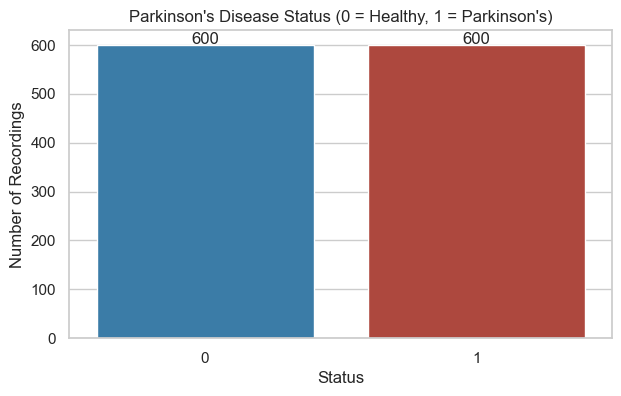

In [2]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='status', data=df, palette=['#2980b9', '#c0392b'])
plt.title("Parkinson's Disease Status (0 = Healthy, 1 = Parkinson's)")
plt.xlabel("Status")
plt.ylabel("Number of Recordings")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 2))

plt.savefig(os.path.join(VIZ_DIR, "01_status_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

## 2. Fundamental Vocal Frequencies
Boxplots comparing average (`MDVP:Fo(Hz)`), maximum (`MDVP:Fhi(Hz)`), and minimum (`MDVP:Flo(Hz)`) pitch across groups.

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_3280\636490767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=col, data=df, palette=['#2980b9', '#c0392b'])
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_3280\636490767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=col, data=df, palette=['#2980b9', '#c0392b'])
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_3280\636490767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=col, data=df, palette=['#2980b9', '#c0392b'])


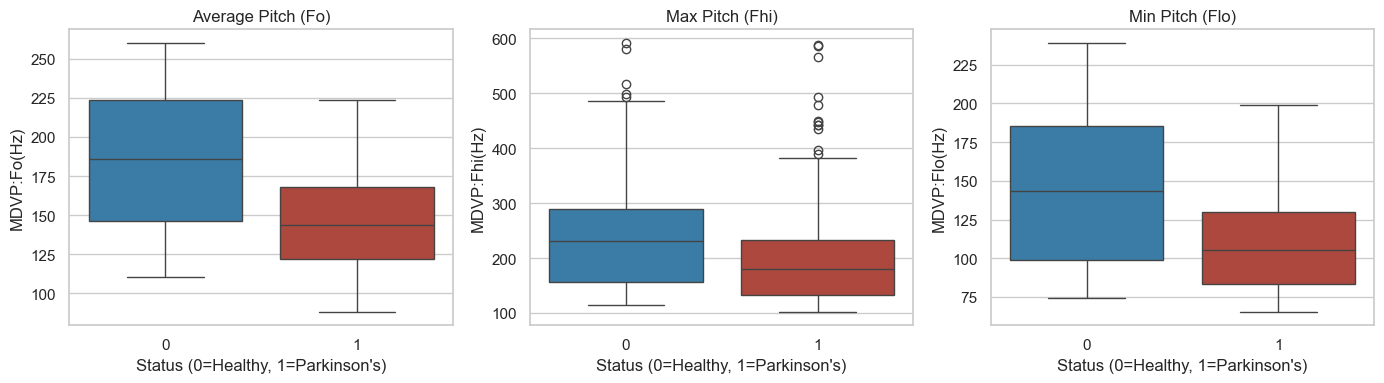

In [3]:
freq_cols = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)']
titles = ['Average Pitch (Fo)', 'Max Pitch (Fhi)', 'Min Pitch (Flo)']

plt.figure(figsize=(14, 4))
for i, (col, title) in enumerate(zip(freq_cols, titles), 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='status', y=col, data=df, palette=['#2980b9', '#c0392b'])
    plt.title(title)
    plt.xlabel("Status (0=Healthy, 1=Parkinson's)")

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "02_fundamental_frequencies.png"), dpi=300, bbox_inches='tight')
plt.show()

## 3. Key Non-Linear & Noise Biomarkers
Comparing Pitch Period Entropy (`PPE`), `spread1`, and Harmonics-to-Noise Ratio (`HNR`).

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_3280\3672296616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=col, data=df, palette=['#2980b9', '#c0392b'])
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_3280\3672296616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=col, data=df, palette=['#2980b9', '#c0392b'])
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_3280\3672296616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=col, data=df, palette=['#2980b9', '#c0392b'])


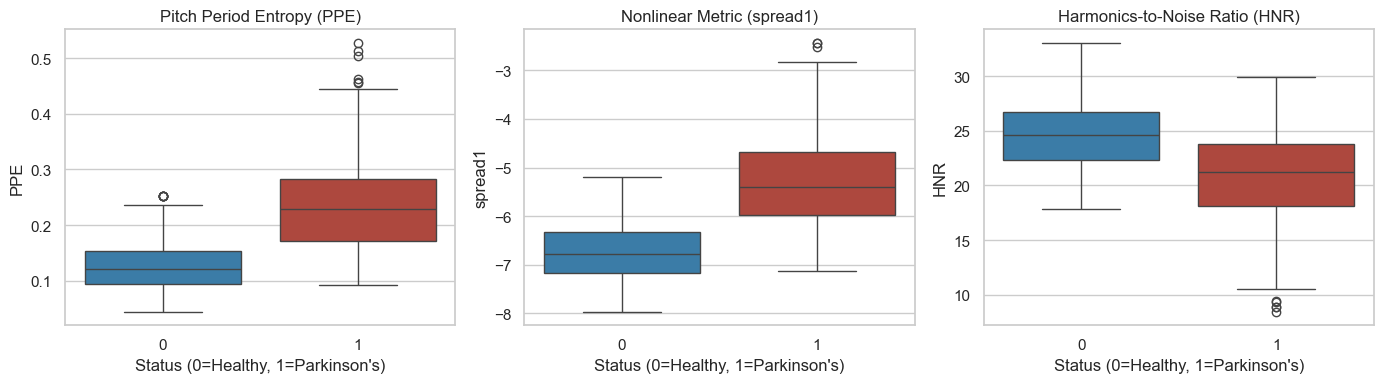

In [4]:
biomarkers = ['PPE', 'spread1', 'HNR']
titles = ['Pitch Period Entropy (PPE)', 'Nonlinear Metric (spread1)', 'Harmonics-to-Noise Ratio (HNR)']

plt.figure(figsize=(14, 4))
for i, (col, title) in enumerate(zip(biomarkers, titles), 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='status', y=col, data=df, palette=['#2980b9', '#c0392b'])
    plt.title(title)
    plt.xlabel("Status (0=Healthy, 1=Parkinson's)")

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "03_nonlinear_biomarkers.png"), dpi=300, bbox_inches='tight')
plt.show()

## 4. Acoustic Features Correlation Matrix
Correlation heatmap for all 22 vocal features.

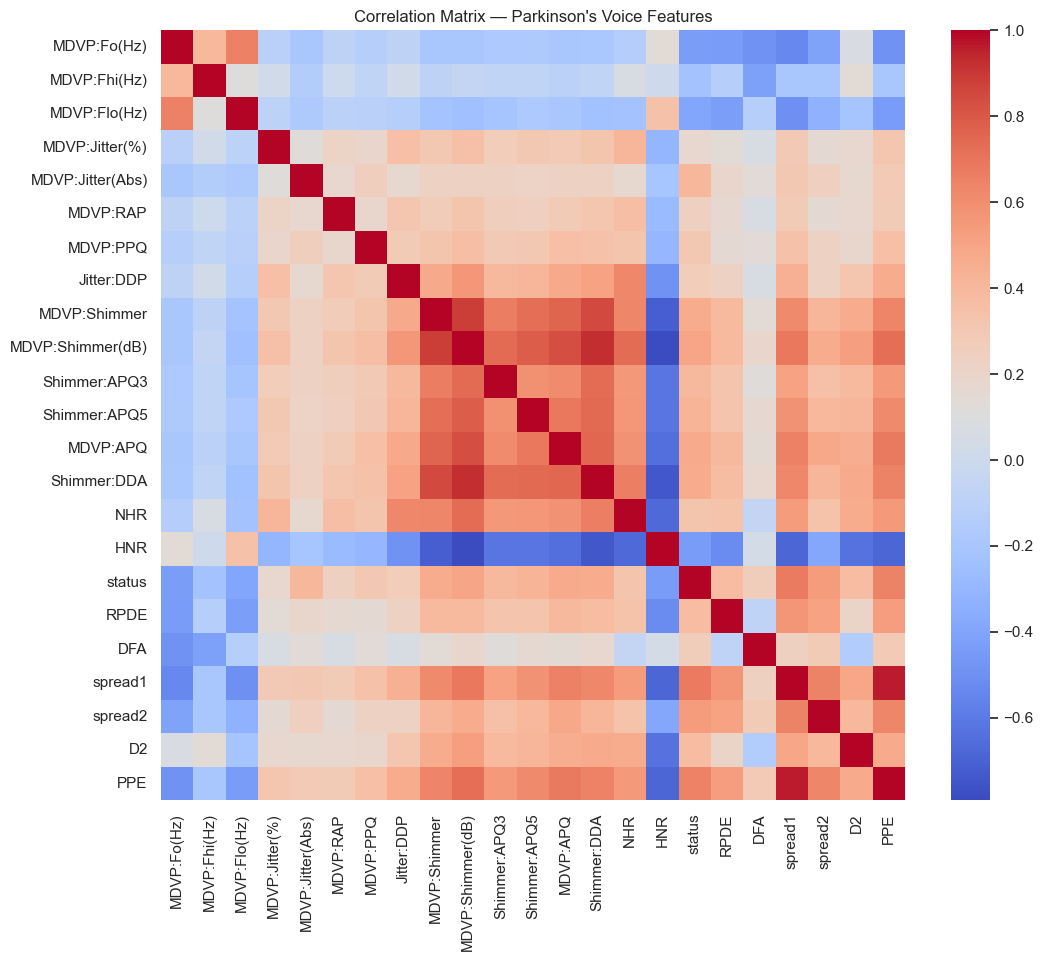

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix — Parkinson's Voice Features")
plt.savefig(os.path.join(VIZ_DIR, "04_acoustic_correlation_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

## 5. Non-Linear Separation: `spread1` vs `PPE`
Shows clear separation between healthy controls and Parkinson's patients.

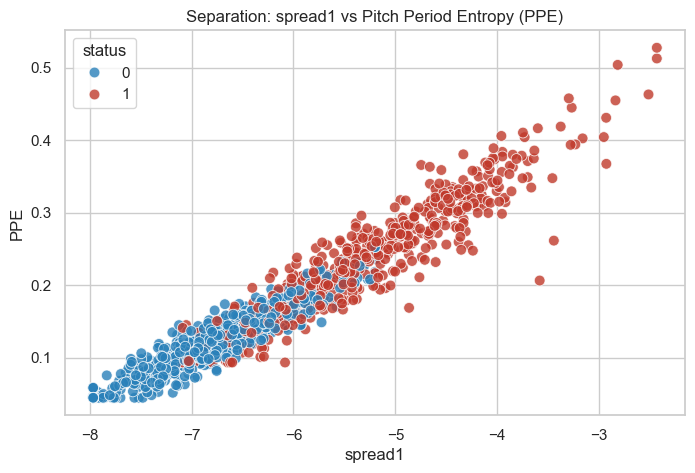

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='spread1', y='PPE', hue='status', data=df, palette=['#2980b9', '#c0392b'], alpha=0.8, s=60)
plt.title("Separation: spread1 vs Pitch Period Entropy (PPE)")
plt.xlabel("spread1")
plt.ylabel("PPE")
plt.savefig(os.path.join(VIZ_DIR, "05_ppe_vs_spread1_separation.png"), dpi=300, bbox_inches='tight')
plt.show()